# Non-Linearity, Visualized Five Different Ways

The core idea we want to lock down today is this:

> **A non-linearity takes a straight line and bends it.
> Add many bent lines together, and you can draw any shape you want.**

That's the whole thing. Everything else — decision boundaries, universal approximation, "deep networks are powerful" — is a consequence of this single idea.

We'll see it from five angles:

1. **One neuron, one bend** — what each activation literally does to a line.
2. **Many bends added together** — build a zigzag by hand from 3 ReLU neurons.
3. **Fitting a curve** — watch a network approximate sin(x) better and better as we add neurons.
4. **2D decision boundaries** — the same idea, but now bends happen in input space.
5. **Space-warping** — a bonus angle: non-linearity bends the *space itself* so stubborn data becomes separable.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons, make_circles

torch.manual_seed(0)
np.random.seed(0)

---
## Angle 1 — One Neuron Bends One Line

A neuron before activation is just a line:

$$
z = w \cdot x + b
$$

The **activation** is a function applied to $z$ afterward. Let's literally look at what each common activation does to the same line $z = 2x - 1$.

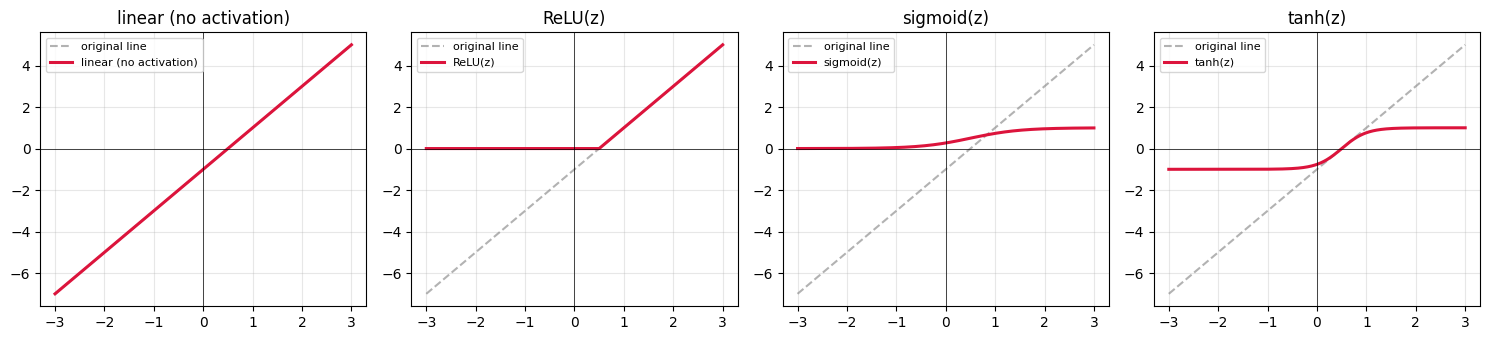

In [10]:
x = np.linspace(-3, 3, 400)
z = 2 * x - 1                              # the "line" a neuron computes

activations = {
    "linear (no activation)": z,
    "ReLU(z)":    np.maximum(0, z),
    "sigmoid(z)": 1 / (1 + np.exp(-z)),
    "tanh(z)":    np.tanh(z),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, (name, y) in zip(axes, activations.items()):
    ax.plot(x, z, '--', color='gray', alpha=0.6, label='original line')
    ax.plot(x, y, color='crimson', linewidth=2.2, label=name)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(name); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**What just happened:**

| Activation | What it does to the line |
|---|---|
| **Linear** | Nothing. Line stays a line. |
| **ReLU** | Sharply snaps the negative half to zero. **One crisp bend** at the x-intercept. |
| **Sigmoid** | Smoothly squashes the line into the range (0, 1). **Soft S-shape.** |
| **Tanh** | Same as sigmoid but centered at 0 and squashing to (-1, 1). |

Every activation has its own way of bending, but they all do the same fundamental thing: **they turn a line into a non-straight shape.** That's the tool.

But one bend isn't much. What can we actually build with it?

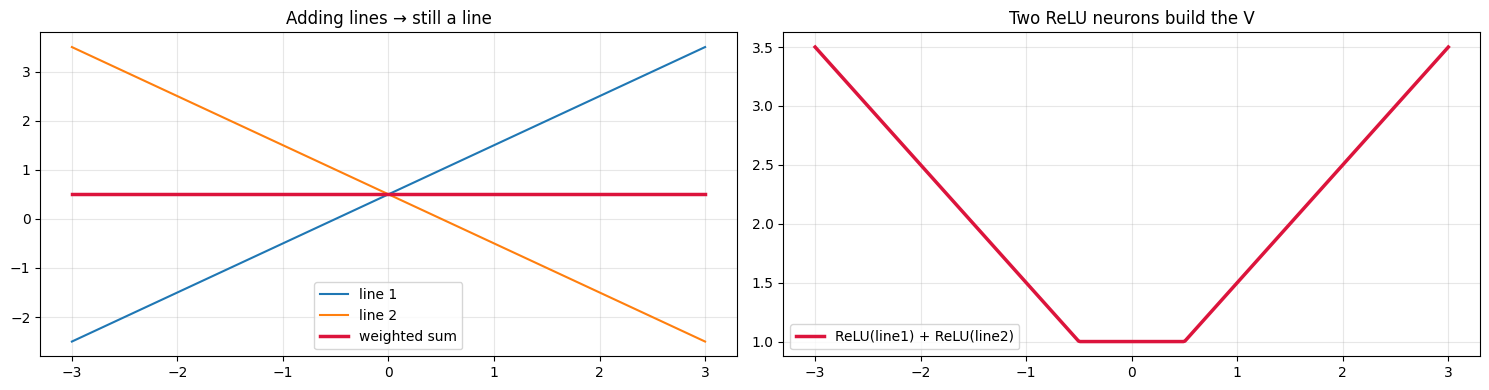

In [19]:
x = np.linspace(-3, 3, 400)
line1 =  1.0 * x + 0.5
line2 = -1.0 * x + 0.5

weighted_sum = 0.5 * line1 + 0.5 * line2   # what a neural net layer can do
via_relu     = np.maximum(0, line1) + np.maximum(0, line2)  # two ReLU neurons!

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(x, line1, label='line 1'); axes[0].plot(x, line2, label='line 2')
axes[0].plot(x, weighted_sum, color='crimson', linewidth=2.5, label='weighted sum')
axes[0].set_title("Adding lines → still a line"); axes[0].legend(); axes[0].grid(alpha=0.3)


axes[1].plot(x, via_relu, color='crimson', linewidth=2.5, label='ReLU(line1) + ReLU(line2)')
axes[1].set_title("Two ReLU neurons build the V"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

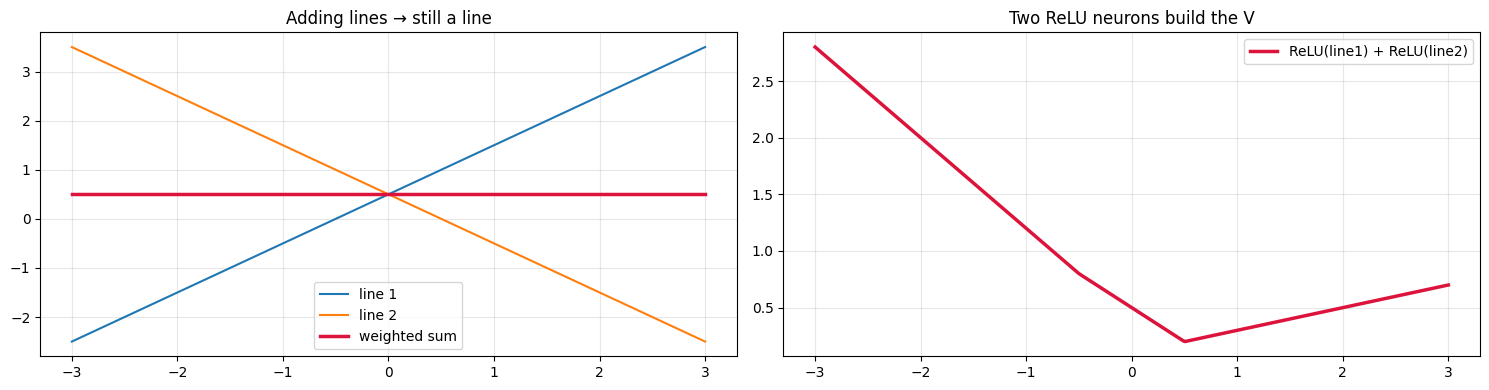

In [31]:
x = np.linspace(-3, 3, 400)
line1 =  1.0 * x + 0.5
line2 = -1.0 * x + 0.5

weighted_sum = 0.5 * line1 + 0.5 * line2   # what a neural net layer can do
via_relu     = 0.2 * np.maximum(0, line1) + 0.8 * np.maximum(0, line2)  # two ReLU neurons!

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(x, line1, label='line 1'); axes[0].plot(x, line2, label='line 2')
axes[0].plot(x, weighted_sum, color='crimson', linewidth=2.5, label='weighted sum')
axes[0].set_title("Adding lines → still a line"); axes[0].legend(); axes[0].grid(alpha=0.3)


axes[1].plot(x, via_relu, color='crimson', linewidth=2.5, label='ReLU(line1) + ReLU(line2)')
axes[1].set_title("Two ReLU neurons build the V"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## Angle 2 — Many Bends Add Up

Here's the magic: a hidden layer in a neural network has **many** neurons, each with its own $w$ and $b$ — so each one bends the line at a **different place**, with a **different steepness**.

The next layer combines them with a weighted sum:

$$
\text{output}(x) = v_1 \cdot \text{ReLU}(w_1 x + b_1) + v_2 \cdot \text{ReLU}(w_2 x + b_2) + v_3 \cdot \text{ReLU}(w_3 x + b_3) + \dots
$$

So the final output is a **sum of bent lines**. Let's build one by hand with just 3 ReLU neurons and see what shape comes out.

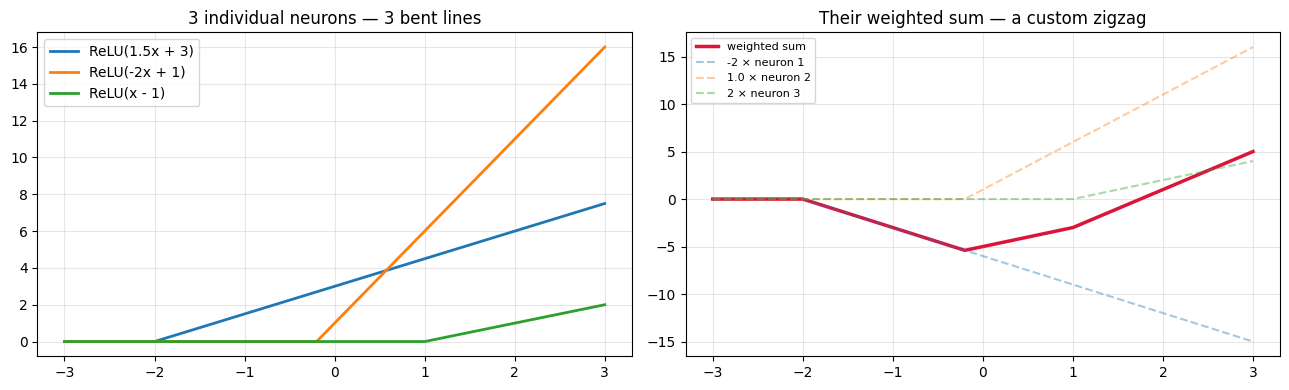

In [41]:
x = np.linspace(-3, 3, 400)

# Three ReLU neurons, each with its own (w, b). Each bends at a different place.
n1 = np.maximum(0,  1.5 * x + 3.0)     # bends at x = -2,  slope +1.5
n2 = np.maximum(0, 5.0 * x + 1.0)     # bends at x = 0.5, slope -2.0 (flips direction)
n3 = np.maximum(0,  1.0 * x - 1.0)     # bends at x = 1,   slope +1.0

# Output-layer weights — how much of each bent line we mix in
#v1, v2, v3 = 1.0, 1.0, -1.5
v1 = -2; v2 = 1.0; v3 = 2
combined = v1 * n1 + v2 * n2 + v3 * n3

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# LEFT: each neuron's individual bent line
axes[0].plot(x, n1, label='ReLU(1.5x + 3)',  linewidth=2)
axes[0].plot(x, n2, label='ReLU(-2x + 1)',   linewidth=2)
axes[0].plot(x, n3, label='ReLU(x - 1)',     linewidth=2)
axes[0].set_title("3 individual neurons — 3 bent lines")
axes[0].grid(alpha=0.3); axes[0].legend()

# RIGHT: the weighted sum
axes[1].plot(x, combined, color='crimson', linewidth=2.5, label='weighted sum')
axes[1].plot(x, n1 * v1, '--', alpha=0.4, label=f'{v1} × neuron 1')
axes[1].plot(x, n2 * v2, '--', alpha=0.4, label=f'{v2} × neuron 2')
axes[1].plot(x, n3 * v3, '--', alpha=0.4, label=f'{v3} × neuron 3')
axes[1].set_title("Their weighted sum — a custom zigzag")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

On the left, three innocent bent lines. On the right, their weighted combination — a zigzag with **three distinct kinks**, one contributed by each neuron.

And that's the whole trick. If we want 10 kinks, we use 10 neurons. If we want 1000 kinks so our shape looks completely smooth, we use 1000 neurons. The more neurons in the hidden layer, the more bends we have available, and the more elaborate the shape we can draw.

---
## Angle 3 — Watch the Bends Approximate a Real Curve

Let's make this concrete. We'll take a real curve — $\sin(x)$ — and train tiny neural networks to fit it. The only thing we'll vary is the **number of hidden neurons** (= the number of bends available).

In [3]:
# Target: sin(x) on [-pi, pi]
x_data = torch.linspace(-np.pi, np.pi, 200).unsqueeze(1)
y_data = torch.sin(x_data)

def fit_sin_with_n_neurons(n_hidden, steps=3000):
    torch.manual_seed(3)
    model = nn.Sequential(
        nn.Linear(1, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 1),
    )
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(steps):
        opt.zero_grad()
        loss = ((model(x_data) - y_data) ** 2).mean()
        loss.backward()
        opt.step()
    with torch.no_grad():
        return model(x_data).squeeze().numpy()
        
        # print weights for each neuron in the 3-neuron example
    #print("Neuron 1 weights:", model[0].weight[0].item(), model[0].bias[0].item())
    #print("Neuron 2 weights:", model[0].weight[1].item(), model[0].bias[1].item())
    #print("Neuron 3 weights:", model[0].weight[2].item(), model[0].bias[2].item())

# Fit with 1, 3, 10, 50 hidden neurons
widths = [1, 3, 10, 50]
predictions = {n: fit_sin_with_n_neurons(n) for n in widths}

In [6]:
def debug_fit_sin_with_n_neurons(n_hidden, steps=3000):
    torch.manual_seed(3)
    model = nn.Sequential(
        nn.Linear(1, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 1),
    )
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(steps):
        opt.zero_grad()
        loss = ((model(x_data) - y_data) ** 2).mean()
        loss.backward()
        opt.step()
    return model

In [10]:
model = debug_fit_sin_with_n_neurons(10)

In [11]:
model[0].weight.shape, model[0].bias.shape, model[2].weight.shape, model[2].bias.shape

(torch.Size([10, 1]), torch.Size([10]), torch.Size([1, 10]), torch.Size([1]))

In [53]:
model[2].weight.shape

torch.Size([2, 16])

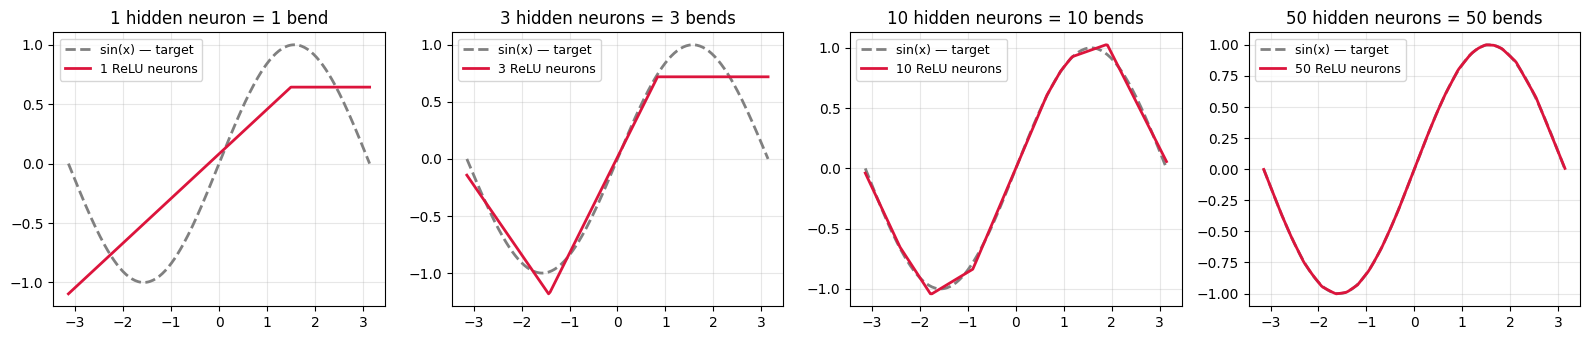

In [45]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, n in zip(axes, widths):
    ax.plot(x_data.squeeze(), y_data.squeeze(), '--', color='gray',
            linewidth=2, label='sin(x) — target')
    ax.plot(x_data.squeeze(), predictions[n], color='crimson',
            linewidth=2, label=f'{n} ReLU neurons')
    ax.set_title(f"{n} hidden neuron{'s' if n > 1 else ''} = {n} bend{'s' if n > 1 else ''}")
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Read left to right:

- **1 neuron:** we get exactly **one bend**. Can't approximate a wave with one kink — this is the best it can do.
- **3 neurons:** three bends. Starting to trace the overall shape.
- **10 neurons:** ten bends — the fit is now excellent, you can barely see the piecewise-linear structure.
- **50 neurons:** fifty bends, so closely packed the output looks perfectly smooth.

This is what mathematicians call the **universal approximation theorem** ("given enough neurons, a neural network can approximate any continuous function"), but really it's just: *more bends = more shape control.*

### Peek behind the curtain — see the individual bends adding up

Let's visualize what's happening *inside* the 10-neuron network. We'll plot each hidden neuron's contribution, then show how they sum to the final fit.

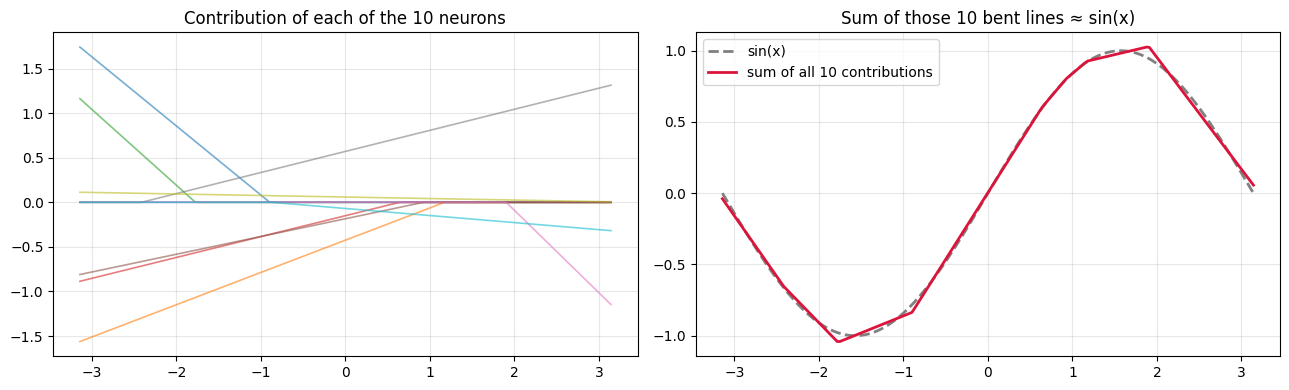

In [12]:
torch.manual_seed(3)
model = nn.Sequential(nn.Linear(1, 10), nn.ReLU(), nn.Linear(10, 1))
opt = torch.optim.Adam(model.parameters(), lr=0.01)
for _ in range(3000):
    opt.zero_grad()
    loss = ((model(x_data) - y_data) ** 2).mean()
    loss.backward(); opt.step()

with torch.no_grad():
    # Outputs of the hidden ReLU layer — shape (200, 10)
    hidden = torch.relu(model[0](x_data))
    # Output-layer weights — shape (1, 10)
    out_w = model[2].weight.squeeze()
    # Each neuron's contribution to the final output
    contributions = hidden * out_w   # shape (200, 10)
    final = model(x_data).squeeze()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# LEFT: each neuron's weighted contribution
for i in range(10):
    axes[0].plot(x_data.squeeze(), contributions[:, i], alpha=0.6, linewidth=1.2)
axes[0].set_title("Contribution of each of the 10 neurons")
axes[0].grid(alpha=0.3)

# RIGHT: their sum vs target
axes[1].plot(x_data.squeeze(), y_data.squeeze(), '--', color='gray',
             linewidth=2, label='sin(x)')
axes[1].plot(x_data.squeeze(), final, color='crimson', linewidth=2,
             label='sum of all 10 contributions')
axes[1].set_title("Sum of those 10 bent lines ≈ sin(x)")
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

The left plot is the cast. The right plot is what happens when they act together.

Each bent line on its own looks like nothing special — but stack them with the right weights, and you get $\sin(x)$.

On the left, the hopeless original: a ring inside a ring. No line works.

On the right, the same points — but plotted using the 3 hidden neurons' outputs as new coordinates. The two classes are now **pulled apart into separate regions of 3D space**, and a simple plane slices between them. That final plane is exactly what the output layer computes.

So non-linearity doesn't *just* bend curves — it bends the **space**. The network's final layer always draws a straight hyperplane; all the cleverness lives in how the earlier non-linear layers have reshaped the space to make that straight cut the right answer.

---
## Putting It All Together

Five angles, one idea:

1. **A single neuron + activation** takes a line and **bends it once**.
2. **A layer of neurons** gives you **many bends**, which a weighted sum combines into any shape.
3. In 1D, this means we can approximate **any curve** (like sin(x)) by adding enough bends.
4. In 2D, the same bends become **folds in input space**, letting the decision boundary wrap around any cluster of points.
5. Equivalently, you can think of the hidden layer as **warping the space** so that what was tangled becomes separable by a straight cut.

The number of hidden neurons controls **how many bends you have to work with**. More neurons = more expressive shapes.

**Next steps when you're back at the notebook:**
- Change ReLU to sigmoid or tanh in the sin(x) demo. The fit still works, but the "bends" are now smooth S-curves, not sharp kinks.
- Increase the noise in the moons dataset. At what width does the network start overfitting (bending around individual noisy points)?
- Try the space-warping demo with only 2 hidden neurons instead of 3. Can circles be separated in 2D? (Hint: usually not cleanly — 3 is the minimum here.)